In [14]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import mannwhitneyu

from utils import FONT, FORMATTER

In [5]:
# ----------------------------------------------------------------------
# Smoothing windows (effective) per environment
# ----------------------------------------------------------------------
WINDOW_TAXI = 100
WINDOW_VSS  = 500
SIGMA_TAXI  = WINDOW_TAXI / 4    # = 25
SIGMA_VSS   = WINDOW_VSS  / 4    # = 62.5


# ----------------------------------------------------------------------
# Core helpers
# ----------------------------------------------------------------------
def smooth_curves(df, value_col, sigma):
    """
    Pivot a long-format dataframe to wide (rows=step, cols=seed),
    forward/backward-fill gaps, then apply a Gaussian filter to each
    seed's column independently.

    Returns
    -------
    index : pd.Index of step values
    smoothed : np.ndarray of shape (n_steps, n_seeds)
    """
    pivoted = df.pivot_table(index="_step", columns="seed", values=value_col)
    pivoted = pivoted.sort_index().ffill().bfill()
    arr = pivoted.values.astype(float)
    smoothed = np.empty_like(arr)
    for j in range(arr.shape[1]):
        smoothed[:, j] = gaussian_filter1d(arr[:, j], sigma=sigma)
    return pivoted.index, smoothed


def plot_panel(ax, configs, value_col, sigma, xlabel, ylabel, title,
               data_dir="/mnt/user-data/uploads"):
    """
    Render one panel: mean curves + per-seed min/max bands for each condition.

    `configs` is a list of (display_name, csv_basename, color) tuples.
    """
    for name, fname, color in configs:
        df = pd.read_csv(f"{data_dir}/{fname}.csv")
        idx, sm = smooth_curves(df, value_col, sigma=sigma)
        mean = sm.mean(axis=1)
        lo   = sm.min(axis=1)
        hi   = sm.max(axis=1)
        ax.plot(idx, mean, label=name, color=color, linewidth=2)
        ax.fill_between(idx, lo, hi, color=color, alpha=0.15)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel, labelpad=1)
    ax.set_title(title)
    ax.legend(loc="lower right", prop=FONT)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)

In [ ]:
api = wandb.Api()
setups = {
    "TAXI" :{"obj": "ep_info/Objective", "name": "taxi_nominal"},
    "TAXI_ROBUST1" :{"obj": "ep_info/Objective", "name": "taxi_optimistic"},
    "TAXI_ROBUST2" :{"obj": "ep_info/Objective", "name": "taxi_pessimistic"},
    "VSS" :{"obj": "ep_info/Goal", "name": "vss_nominal"},
    "ROBUSTNESS_MOVE1" :{"obj": "ep_info/Goal", "name": "vss_move_minus25"},
    "ROBUSTNESS_MOVE2" :{"obj": "ep_info/Goal", "name": "vss_move_plus25"},
    "ROBUSTNESS_BALL1" :{"obj": "ep_info/Goal", "name": "vss_goal_plus25"},
    "ROBUSTNESS_BALL2" :{"obj": "ep_info/Goal", "name": "vss_goal_minus25"},
}

for env, setup in setups.items():
    runs = api.runs("goncamateus/DyLam", filters={"config.env": env, "config.setup": "Dylam"})

    dfs = []
    for run in runs:
        hist = run.history(keys=[setup["obj"], "_step"])
        hist["seed"] = run.config.get("seed", run.id)
        dfs.append(hist)

    pd.concat(dfs).to_csv(f"{setup['name']}.csv", index=False)

wandb: Currently logged in as: goncamateus to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Saved robustness_curves.pdf and robustness_curves.png.


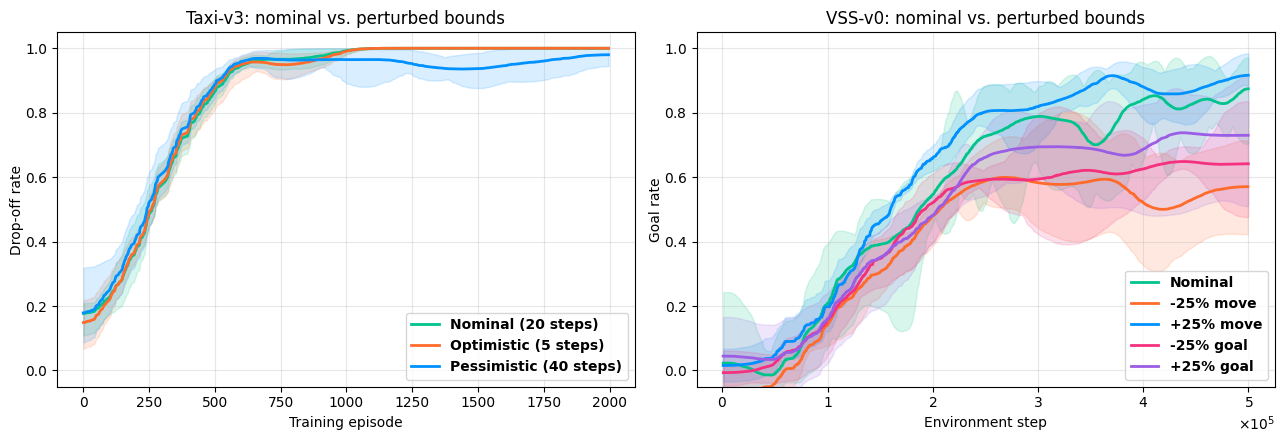

In [ ]:
"""
Robustness curves for DyLam RQ3 experiments.

Per-environment Gaussian smoothing windows:
  - Taxi-v3: ~100-point window (sigma = 25)
  - VSS-v0:  ~250-point window (sigma = 62.5)

Convention: sigma = window / 4 so that ~95% of the kernel mass falls
within ±2σ ≈ `window` points. Per-seed smoothing is applied before
aggregation so that the min/max bands reflect actual seed variability,
not residual noise.

Expected CSV format (one file per condition):
    _step, ep_info/<metric>, seed
where each row is one logged datapoint and each seed contributes its
own time series.
"""

# ----------------------------------------------------------------------
# Build the two-panel robustness figure
# ----------------------------------------------------------------------
def main(out_pdf="robustness_curves.pdf", out_png="robustness_curves.png",
         data_dir="."):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    plot_panel(
        axes[0],
        configs=[
            ("Nominal (20 steps)",     "taxi_nominal",     "#00C48C"),
            ("Optimistic (5 steps)",   "taxi_optimistic",  "#FF6B2B"),
            ("Pessimistic (40 steps)", "taxi_pessimistic", "#0091FF"),
        ],
        value_col="ep_info/Objective",
        sigma=SIGMA_TAXI,
        xlabel="Training episode",
        ylabel="Drop-off rate",
        title="Taxi-v3: nominal vs. perturbed bounds",
        data_dir=data_dir,
    )

    plot_panel(
        axes[1],
        configs=[
            ("Nominal",     "vss_nominal",  "#00C48C"),
            (r"-25% move", "move_minus25",  "#FF6B2B"),
            (r"+25% move", "move_plus25",   "#0091FF"),
            (r"-25% goal", "goal_minus25",  "#F5317F"),
            (r"+25% goal", "goal_plus25",   "#9B5DE5"),

        ],
        value_col="ep_info/Goal",
        sigma=SIGMA_VSS,
        xlabel="Environment step",
        ylabel="Goal rate",
        title="VSS-v0: nominal vs. perturbed bounds",
        data_dir=data_dir,
    )

    plt.tight_layout()
    plt.gca().yaxis.set_major_formatter(FORMATTER)
    plt.gca().xaxis.set_major_formatter(FORMATTER)
    plt.savefig(out_pdf, bbox_inches="tight")
    plt.savefig(out_png, dpi=120, bbox_inches="tight")
    print(f"Saved {out_pdf} and {out_png}.")


if __name__ == "__main__":
    main()

In [12]:
results = {
    "Taxi": {
        "nominal": [],
        "optimistic": [],
        "pessimistic": [],
    },
    "VSS": {
        "nominal": [],
        "move_minus25": [],
        "move_plus25": [],
        "goal_minus25": [],
        "goal_plus25": [],
    },
}

In [13]:
for setup, res in results["Taxi"].items():
    df = pd.read_csv(f"taxi_{setup}.csv")
    _, sm = smooth_curves(df, "ep_info/Objective", sigma=SIGMA_TAXI)
    mean = sm.mean(axis=1)
    results["Taxi"][setup] = mean[int(mean.shape[0]*0.9):]

for setup, res in results["VSS"].items():
    df = pd.read_csv(f"vss_{setup}.csv")
    _, sm = smooth_curves(df, "ep_info/Goal", sigma=SIGMA_VSS)
    mean = sm.mean(axis=1)
    results["VSS"][setup] = mean[int(mean.shape[0]*0.9):]

In [15]:
ALPHA = 0.05
REFERENCE = "nominal"  # we always compare DyLam vs. each baseline

print("=" * 60)
print(f"Mann-Whitney U tests (two-sided, α={ALPHA})")
print(f"Reference method: {REFERENCE}")
print("=" * 60)

latex_rows = []

for env_name, methods in results.items():
    print(f"\n--- {env_name} ---")
    dylam_scores = methods[REFERENCE]

    for baseline_name, baseline_scores in methods.items():
        if baseline_name == REFERENCE:
            continue

        stat, p = mannwhitneyu(dylam_scores, baseline_scores, alternative="two-sided")
        significant = p < ALPHA
        direction = ">" if np.median(dylam_scores) > np.median(baseline_scores) else "<"

        print(
            f"  DyLam {direction} {baseline_name:12s}  |  "
            f"U={stat:.0f}  p={p:.4f}  "
            f"{'*SIGNIFICANT*' if significant else ''}"
        )

        # For the LaTeX table
        marker = r"$^{*}$" if significant else ""
        latex_rows.append(
            f"  {env_name} & {baseline_name} & "
            f"{np.mean(dylam_scores):.3f} & "
            f"{np.mean(baseline_scores):.3f} & "
            f"{p:.4f}{marker} \\\\"
        )


Mann-Whitney U tests (two-sided, α=0.05)
Reference method: nominal

--- Taxi ---
  DyLam < optimistic    |  U=1250  p=1.0000  
  DyLam > pessimistic   |  U=2500  p=0.0000  *SIGNIFICANT*

--- VSS ---
  DyLam > move_minus25  |  U=124250  p=0.0000  *SIGNIFICANT*
  DyLam < move_plus25   |  U=0  p=0.0000  *SIGNIFICANT*
  DyLam > goal_minus25  |  U=124250  p=0.0000  *SIGNIFICANT*
  DyLam > goal_plus25   |  U=124250  p=0.0000  *SIGNIFICANT*
